In [2]:
#1 Setup
import pandas as pd, numpy  as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path("../data/raw")
FIGS = Path("../reports/figures")
FIGS.mkdir(parents=True, exist_ok=True)

train = pd.read_csv(DATA/"train.csv")

#2 Overview
train.head()
train.info()
train.describe(include="all")

# Missing values
train.isna().mean().sort_values(ascending=False)

# 3) Simple cleaning
train["Embarked"] = train["Embarked"].fillna(train["Embarked"].mode()[0])
train["Fare"] = train["Fare"].fillna(train["Fare"].median())

# 4) Feature asisten untuk analisis (tanpa modeling)
bins = [0, 12, 18, 35, 50, 80]
labels = ["Child","Teen","YoungAdult","Adult","Senior"]
train["AgeBucket"] = pd.cut(train["Age"], bins=bins, labels=labels)

# 5) Contoh insight numerik cepat
survival_rate = train["Survived"].mean()
survival_by_sex = train.groupby("Sex")["Survived"].mean().sort_values(ascending=False)
survival_by_pclass = train.groupby("Pclass")["Survived"].mean()
survival_by_agebucket = train.groupby("AgeBucket")["Survived"].mean()

survival_rate, survival_by_sex, survival_by_pclass, survival_by_agebucket

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


C:\Users\kglan\AppData\Local\Temp\ipykernel_25816\1295309248.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_by_agebucket = train.groupby("AgeBucket")["Survived"].mean()


(np.float64(0.3838383838383838),
 Sex
 female    0.742038
 male      0.188908
 Name: Survived, dtype: float64,
 Pclass
 1    0.629630
 2    0.472826
 3    0.242363
 Name: Survived, dtype: float64,
 AgeBucket
 Child         0.579710
 Teen          0.428571
 YoungAdult    0.382682
 Adult         0.398693
 Senior        0.343750
 Name: Survived, dtype: float64)

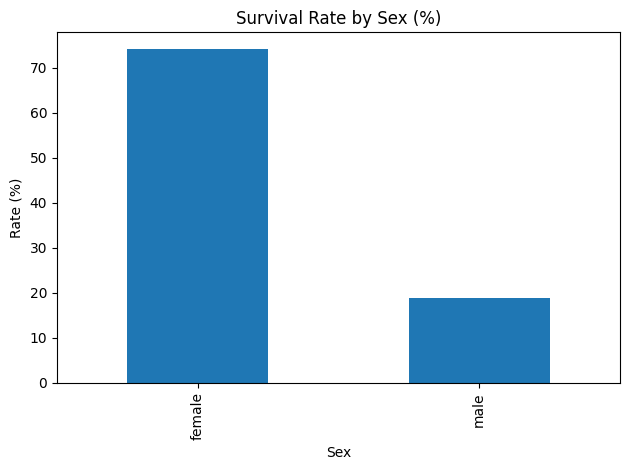

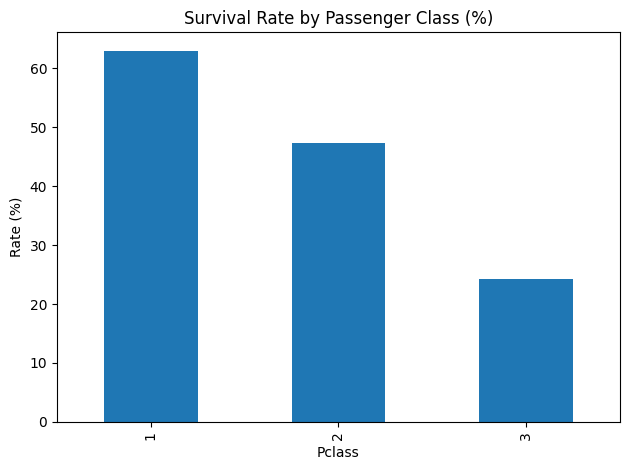

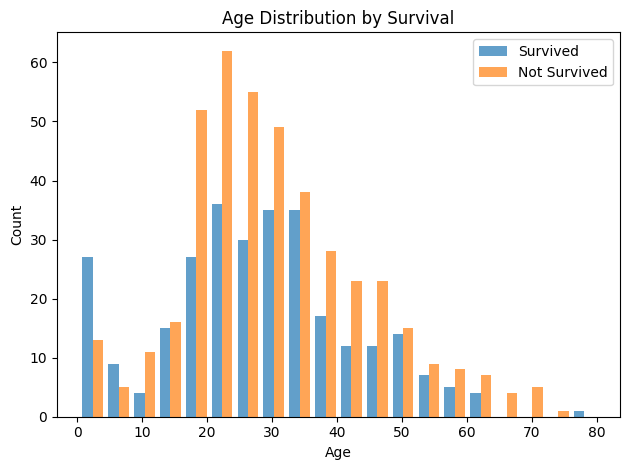

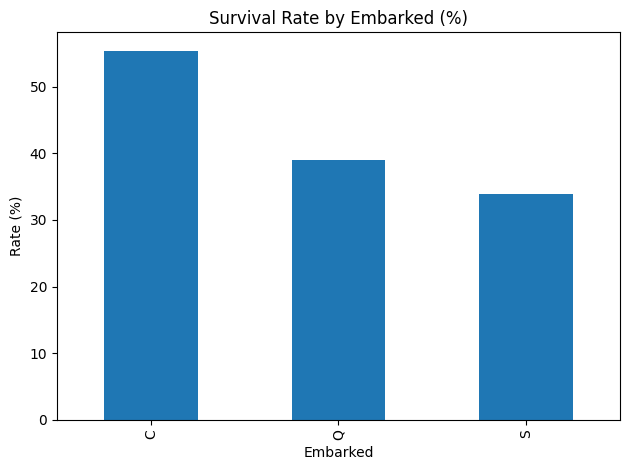

C:\Users\kglan\AppData\Local\Temp\ipykernel_25816\2067383951.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


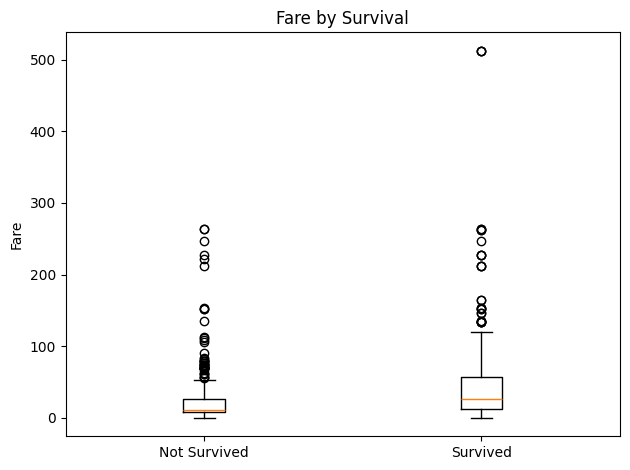

In [3]:
# 1) Survival rate by Sex
ax = (train.groupby("Sex")["Survived"].mean()*100).plot(kind="bar")
plt.title("Survival Rate by Sex (%)")
plt.ylabel("Rate (%)")
plt.tight_layout()
plt.savefig(FIGS/"survival_by_sex.png", dpi=150)
plt.show()

# 2) Survival rate by Pclass
ax = (train.groupby("Pclass")["Survived"].mean()*100).plot(kind="bar")
plt.title("Survival Rate by Passenger Class (%)")
plt.ylabel("Rate (%)"); plt.xlabel("Pclass")
plt.tight_layout(); plt.savefig(FIGS/"survival_by_pclass.png", dpi=150); plt.show()

# 3) Age distribution vs Survived (hist)
surv = train[train["Survived"]==1]["Age"].dropna()
nons = train[train["Survived"]==0]["Age"].dropna()
plt.hist([surv, nons], bins=20, label=["Survived","Not Survived"], alpha=0.7)
plt.title("Age Distribution by Survival")
plt.xlabel("Age"); plt.ylabel("Count"); plt.legend()
plt.tight_layout(); plt.savefig(FIGS/"age_distribution.png", dpi=150); plt.show()

# 4) Survival by Embarked
ax = (train.groupby("Embarked")["Survived"].mean()*100).plot(kind="bar")
plt.title("Survival Rate by Embarked (%)")
plt.ylabel("Rate (%)"); plt.xlabel("Embarked")
plt.tight_layout(); plt.savefig(FIGS/"survival_by_embarked.png", dpi=150); plt.show()

# 5) Fare vs Survival (boxplot sederhana)
plt.boxplot([
    train[train["Survived"]==0]["Fare"].dropna(),
    train[train["Survived"]==1]["Fare"].dropna()
], labels=["Not Survived","Survived"])
plt.title("Fare by Survival")
plt.ylabel("Fare")
plt.tight_layout(); plt.savefig(FIGS/"fare_by_survival.png", dpi=150); plt.show()